In [1]:
import pandas as pd

df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df["Outcome"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
# Nombre de valeurs égales à 0 par colonne
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


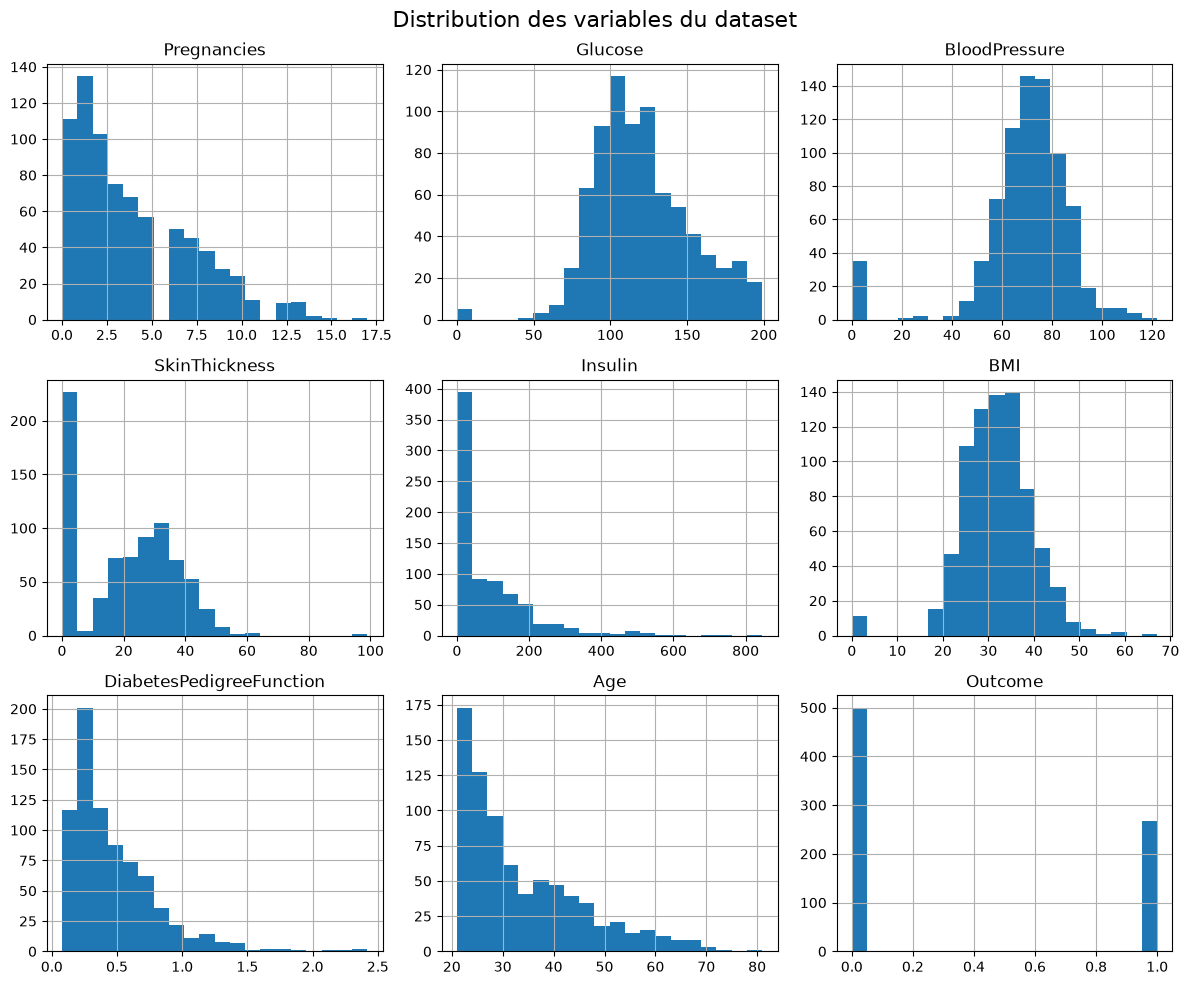

In [57]:
import matplotlib.pyplot as plt
2
 
3
# Histogrammes des variables numériques
4
df.hist(figsize=(12, 10), bins=20)
5
plt.suptitle("Distribution des variables du dataset", fontsize=16)
6
plt.tight_layout()
7
plt.show()



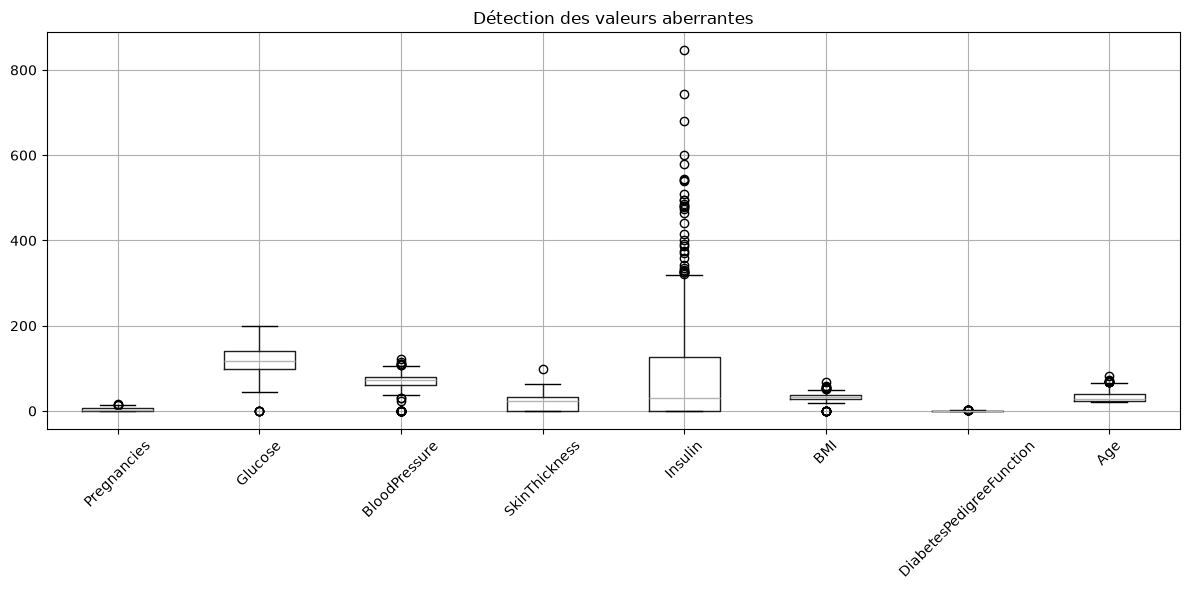

In [60]:
# Boxplots des variables explicatives

plt.figure(figsize=(12, 6))
df.drop(columns="Outcome").boxplot()
plt.title("Détection des valeurs aberrantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
import numpy as np
# Copie du dataset original
df_clean = df.copy()

# Variables dans lesquelles 0 représente une valeur manquante/problématique
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Remplacement des 0 par NaN
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Valeurs manquantes après traitement :")
print(df_clean.isnull().sum())
# Imputation des valeurs manquantes par la médiane

for column in zero_as_missing:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())
print("=========================================")
print("Valeurs manquantes après imputation :")
print(df_clean.isnull().sum())
print("=========================================")
print("Nombre total de valeurs manquantes :", df_clean.isnull().sum().sum())
print("=========================================")
print("Dataset original :", df.shape)
print("Dataset nettoyé  :", df_clean.shape)
print("=========================================")

Valeurs manquantes après traitement :
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Valeurs manquantes après imputation :
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Nombre total de valeurs manquantes : 0
Dataset original : (768, 9)
Dataset nettoyé  : (768, 9)


In [51]:
print("Variables explicatives :")
print(X.columns.tolist())
print("\nVariable cible :")
print(y.name)
# Variables explicatives
X = df_clean.drop("Outcome", axis=1)

# Variable cible
y = df_clean["Outcome"]
print("==================================
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Variables explicatives :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Variable cible :
Outcome
Dimensions de X : (768, 8)
Dimensions de y : (768,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (614, 8)
X_test  : (154, 8)
y_train : (614,)
y_test  : (154,)


In [26]:
from sklearn.linear_model import LogisticRegression

# Création du modèle
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Entraînement du modèle
model_lr.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


In [27]:
# Prédictions sur les données de test
y_pred_lr = model_lr.predict(X_test)

print("Premières prédictions :", y_pred_lr[:10])

Premières prédictions : [1 0 0 0 0 0 0 1 0 1]


In [28]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy de la régression logistique :", accuracy_lr)

Accuracy de la régression logistique : 0.7012987012987013


In [29]:
from sklearn.metrics import precision_score

precision_lr = precision_score(y_test, y_pred_lr)

print("Precision de la régression logistique :", precision_lr)

Precision de la régression logistique : 0.5869565217391305


In [30]:
from sklearn.metrics import recall_score

recall_lr = recall_score(y_test, y_pred_lr)

print("Recall de la régression logistique :", recall_lr)

Recall de la régression logistique : 0.5


In [31]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr)

print("F1-score de la régression logistique :", f1_lr)

F1-score de la régression logistique : 0.54


Matrice de confusion :
[[81 19]
 [27 27]]


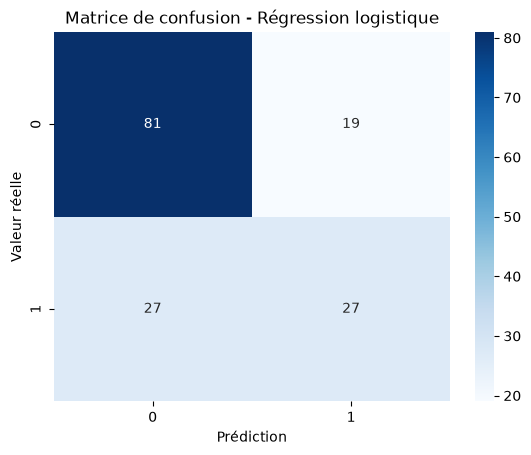

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Matrice de confusion :")
print(cm_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Régression logistique")
plt.show()

In [33]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

print("Arbre de décision entraîné avec succès.")

Arbre de décision entraîné avec succès.


In [34]:
y_pred_dt = model_dt.predict(X_test)

print("Premières prédictions de l'arbre :", y_pred_dt[:10])

Premières prédictions de l'arbre : [1 0 0 1 1 0 0 1 0 1]


In [35]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy de l'arbre de décision :", accuracy_dt)

Accuracy de l'arbre de décision : 0.6818181818181818


In [36]:
from sklearn.metrics import precision_score

precision_dt = precision_score(y_test, y_pred_dt)

print("Precision de l'arbre de décision :", precision_dt)

Precision de l'arbre de décision : 0.5531914893617021


In [37]:
from sklearn.metrics import recall_score

recall_dt = recall_score(y_test, y_pred_dt)

print("Recall de l'arbre de décision :", recall_dt)

Recall de l'arbre de décision : 0.48148148148148145


In [38]:
from sklearn.metrics import f1_score

f1_dt = f1_score(y_test, y_pred_dt)

print("F1-score de l'arbre de décision :", f1_dt)

F1-score de l'arbre de décision : 0.5148514851485149


Matrice de confusion :
[[79 21]
 [28 26]]


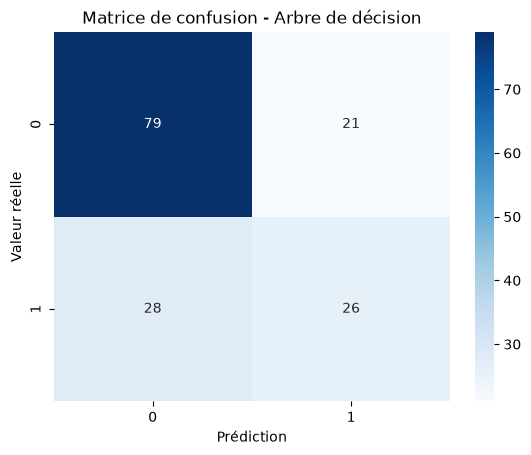

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Matrice de confusion :")
print(cm_dt)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Arbre de décision")
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

print("Random Forest entraînée avec succès.")

Random Forest entraînée avec succès.


In [41]:
y_pred_rf = model_rf.predict(X_test)

print("Premières prédictions de la Random Forest :", y_pred_rf[:10])

Premières prédictions de la Random Forest : [1 0 0 0 0 0 1 1 0 1]


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Résultats de la Random Forest")
print("Accuracy :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1-score :", f1_rf)

Résultats de la Random Forest
Accuracy : 0.7792207792207793
Precision : 0.7272727272727273
Recall : 0.5925925925925926
F1-score : 0.6530612244897959


Matrice de confusion :
[[88 12]
 [22 32]]


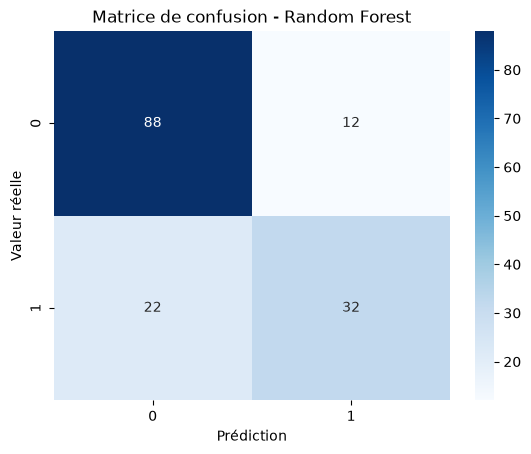

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Matrice de confusion :")
print(cm_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Random Forest")
plt.show()

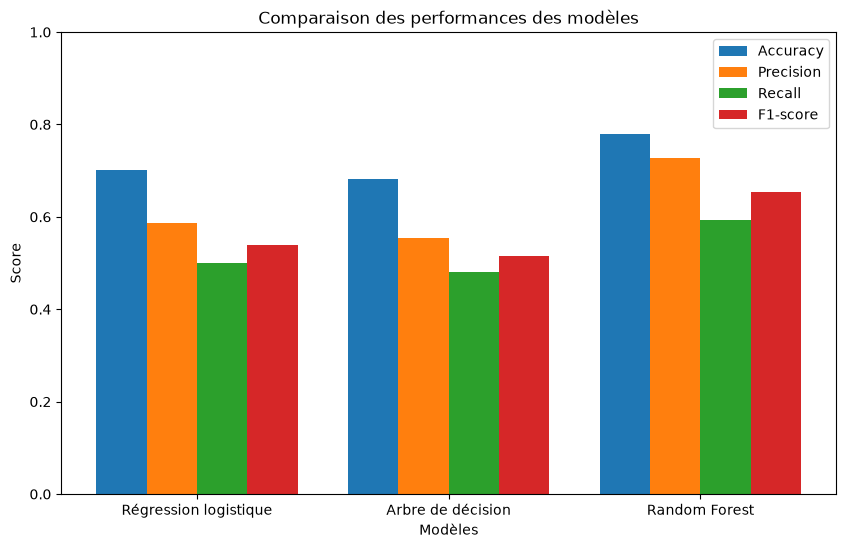

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Résultats des modèles
modeles = ["Régression logistique", "Arbre de décision", "Random Forest"]

accuracy = [accuracy_lr, accuracy_dt, accuracy_rf]
precision = [precision_lr, precision_dt, precision_rf]
recall = [recall_lr, recall_dt, recall_rf]
f1 = [f1_lr, f1_dt, f1_rf]

x = np.arange(len(modeles))
largeur = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*largeur, accuracy, largeur, label="Accuracy")
plt.bar(x - 0.5*largeur, precision, largeur, label="Precision")
plt.bar(x + 0.5*largeur, recall, largeur, label="Recall")
plt.bar(x + 1.5*largeur, f1, largeur, label="F1-score")

plt.xlabel("Modèles")
plt.ylabel("Score")
plt.title("Comparaison des performances des modèles")
plt.xticks(x, modeles)
plt.ylim(0, 1)
plt.legend()

plt.show()

In [45]:
import pandas as pd

resultats = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Arbre de décision",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    "F1-score": [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

resultats

,Modèle,Accuracy,Precision,Recall,F1-score
0,Régression logistique,0.701299,0.586957,0.500000,0.540000
1,Arbre de décision,0.681818,0.553191,0.481481,0.514851
2,Random Forest,0.779221,0.727273,0.592593,0.653061


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilités prédites par chaque modèle
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# Calcul des AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC Régression logistique :", auc_lr)
print("AUC Arbre de décision :", auc_dt)
print("AUC Random Forest :", auc_rf)

AUC Régression logistique : 0.812962962962963
AUC Arbre de décision : 0.6357407407407407
AUC Random Forest : 0.8191666666666666


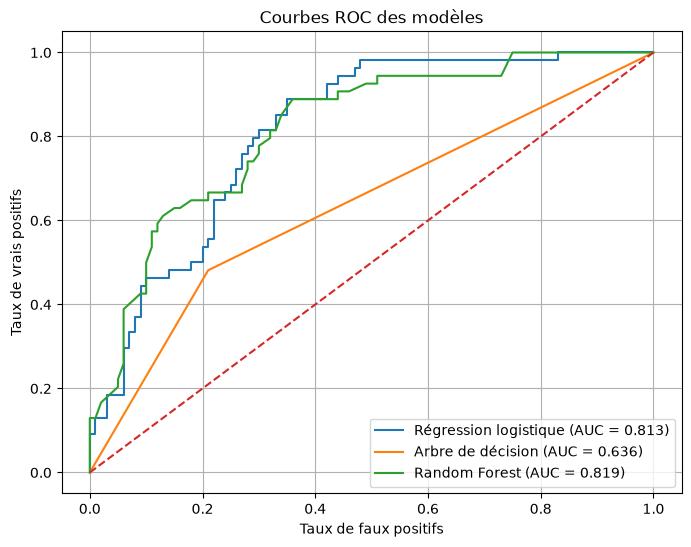

In [47]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcul des courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Tracé
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Régression logistique (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Arbre de décision (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC des modèles")
plt.legend()
plt.grid()

plt.show()

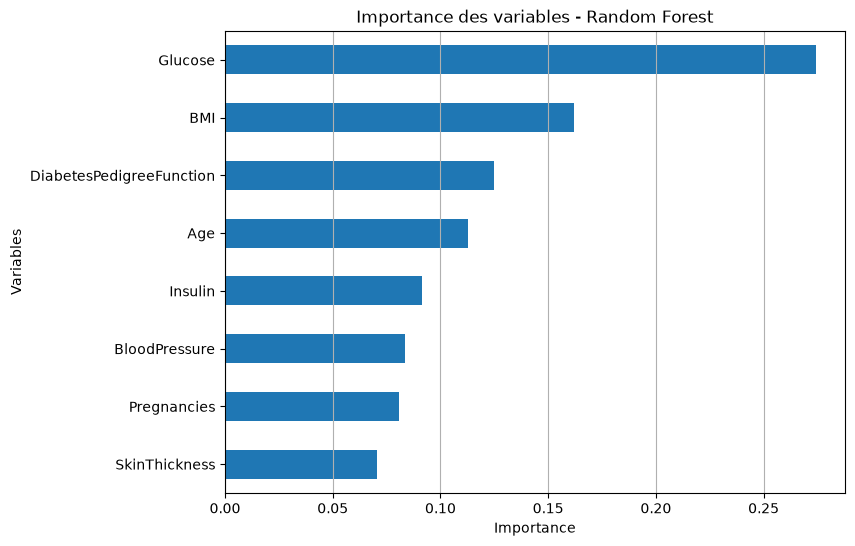

Glucose                     0.274086
BMI                         0.161903
DiabetesPedigreeFunction    0.125020
Age                         0.112985
Insulin                     0.091224
BloodPressure               0.083518
Pregnancies                 0.080795
SkinThickness               0.070468
dtype: float64


In [63]:
plt.figure(figsize=(8, 6))

importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Variables")
plt.title("Importance des variables - Random Forest")
plt.grid(axis="x")

plt.show()
import pandas as pd
import matplotlib.pyplot as plt

# Importance des variables pour la Random Forest
importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)